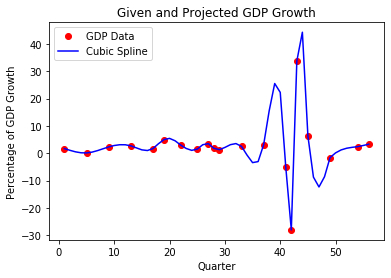

In [3]:
import numpy as np
import matplotlib.pyplot as plt

##This was adapted rom the midterm, midterm was completed first and this was retrofitted to the homework. 

def thomas_algorithm(a, b, c, d):# From Slides
    """ 
    Solve the tridiagonal system using the Thomas algorithm.

    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)

    Returns: solution vector x of length n
    """

    n = len(b)

    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]

    return x



def solveSpline(x, y, xValue):

    h = [] ##empty array 
    for i in range(len(x) - 1): ##number of calculations (h2-h1 type) within array
        h.append(x[i+1] - x[i]) 

    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(len(x) - 2)  # Subdiagonal
    B = np.zeros(len(x) - 2)  # Main diagonal
    C = np.zeros(len(x) - 2)  # Superdiagonal
    D = np.zeros(len(x) - 2)  # Right-hand side vector

    # Populate the tridiagonal matrix coefficients
    count = 0
    for i in range(1, len(x) - 1):
       # count = x[i] 
        #if (i = 1):
        #    A[i - 1] = 0 
        #elif (i > 1):
        ##    for ()
        A[i - 1] =  h[i-1]       # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i])        # Main diagonal
        C[i - 1] = h[i]        # Superdiagonal 
        D[i - 1] = 6 * ( (y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1]  )       # Right-hand side vector


    
    mInterior =  thomas_algorithm(A, B, C, D)
    
    m = np.zeros(len(x))
    for i in range (1, len(x) - 1) :
        m[i] = mInterior[i-1] ##finding inner m values, 


    for i in range (len(x) - 1):
        if (x[i] <= xValue and xValue <= x[i+1]): ##finding which "i" the xValue from input pertains, find the value from the spline using interpolation
        ##solving for the splice 
            S = (
            ( m[i] / (6 * h[i] )) * (x[i+1]  - xValue)**3 +
            ( m[i+1] / ( 6 * h[i]) ) * (xValue - x[i] )**3 +
            ( y[i] / h[i] - m[i] * h[i] / 6) * (x[i+1] - xValue ) +
            ( y[i+1] / h[i] - m[i+1] * h[i] /6 ) * (xValue - x[i] )
            ) ##formula from slide s
            
            return S
        

        
import numpy as np
import matplotlib.pyplot as plt
x = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, ##AI utilized to get values for this array / dataset, as in to extract from slides
              29, 33, 37, 41, 42, 43, 45, 49, 54, 56])

y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

xCompleted = []
for i in range (1, 57):
    xCompleted.append(i)
plt.plot(x, y, 'ro', label="GDP Data")
plt.ylabel("Percentage of GDP Growth")
plt.xlabel("Quarter")
plt.title("Given and Projected GDP Growth")


splineValues = []
for i in range (1, 57):
    splineValues.append(solveSpline(x, y, i))
 

plt.plot(xCompleted, splineValues, 'b-', label="Cubic Spline")

plt.legend()
plt.show()

    